<a href="https://colab.research.google.com/github/The-Abhay/COVID-19-Data-Analysis-Project/blob/main/COVID_19_Data_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Data Analysis Project

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Step 1: Data Cleaning & Feature Engineering

In [ ]:
# Load the dataset
df = pd.read_csv('COVID19_Statistics_200_Rows-1.csv')

In [ ]:
# Inspect structure and summary stats
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Record_ID         200 non-null    int64         
 1   Date              200 non-null    datetime64[ns]
 2   Country           200 non-null    object        
 3   State             200 non-null    object        
 4   Confirmed         200 non-null    int64         
 5   Recovered         200 non-null    int64         
 6   Deaths            200 non-null    int64         
 7   Active            200 non-null    int64         
 8   Tests_Conducted   200 non-null    int64         
 9   Vaccination_Rate  200 non-null    int64         
dtypes: datetime64[ns](1), int64(7), object(2)
memory usage: 15.8+ KB


In [ ]:
df.describe()

,Record_ID,Confirmed,Recovered,Deaths,Active,Tests_Conducted,Vaccination_Rate_%
count,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02,200.00000
mean,100.500000,246900.925000,210518.205000,3766.560000,32852.280000,7.315664e+05,57.95500
std,57.879185,144278.001022,126369.024284,3187.914286,31283.667031,5.357430e+05,25.93988
min,1.000000,1124.000000,847.000000,13.000000,0.000000,5.440000e+03,10.00000
25%,50.750000,114969.750000,98422.750000,1058.000000,8433.250000,3.123678e+05,37.00000
50%,100.500000,246254.000000,213177.500000,3100.000000,23296.000000,6.036515e+05,58.00000
75%,150.250000,374580.750000,312515.500000,5897.500000,47646.000000,1.089873e+06,82.00000
max,200.000000,486407.000000,486353.000000,13969.000000,134405.000000,2.226251e+06,100.00000


In [ ]:
# Convert Date to datetime object
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# Rename column for easier coding access
df.rename(columns={'Vaccination_Rate_%': 'Vaccination_Rate'}, inplace=True)

In [ ]:
# Drop redundant identifier columns if not needed for modeling
df_clean = df.drop(columns=['Record_ID']).copy()

In [ ]:
# Check and remove duplicates (if any)
df_clean.drop_duplicates(inplace=True)

In [ ]:
# Calculate Mortality Rate and Recovery Rate
df_clean['Mortality_Rate'] = (df_clean['Deaths'] / df_clean['Confirmed']) * 100
df_clean['Recovery_Rate'] = (df_clean['Recovered'] / df_clean['Confirmed']) * 100
df_clean['Positivity_Rate'] = (df_clean['Confirmed'] / df_clean['Tests_Conducted']) * 100
df_clean['Mortality_Rate'].head()

,Mortality_Rate
0,1.704407
1,2.205718
2,2.349059
3,1.822421
4,1.411637


In [ ]:
# Aggregation
country_summary = df_clean.groupby('Country')[['Confirmed', 'Deaths', 'Recovered', 'Tests_Conducted']].sum()
print("\nCountry Summary:")
country_summary


Country Summary:


,Confirmed,Deaths,Recovered,Tests_Conducted
Country,,,,
Brazil,7073638,103779,5991955,24072403
India,9042374,135168,7769020,28838049
Japan,10853319,153422,9130537,30119600
UK,12167547,189923,10415496,31115813
USA,10243307,171020,8796633,32167423


# Step 2: Numerical Operations & Outlier Analysis

In [ ]:
# Convert numerical columns to NumPy arrays
confirmed_arr = df_clean['Confirmed'].to_numpy()
deaths_arr = df_clean['Deaths'].to_numpy()

In [ ]:
# Advanced Mathematical Operations
mean_confirmed = float(np.mean(confirmed_arr))
std_confirmed = float(np.std(confirmed_arr))
median_deaths = float(np.median(deaths_arr))

mean_confirmed, std_confirmed, median_deaths

(246900.925, 143916.85401987974, 3100.0)

In [ ]:
# 3. Detect Outliers using Z-score Thresholding (|Z| > 3)
z_scores = np.abs((confirmed_arr - mean_confirmed) / std_confirmed)
outliers = np.where(z_scores > 3)

outliers

(array([], dtype=int64),)

In [ ]:
# Conditional Risk Categorization using np.select
conditions = [
    (df_clean['Mortality_Rate'] < 1.0),
    (df_clean['Mortality_Rate'] >= 1.0) & (df_clean['Mortality_Rate'] <= 2.5),
    (df_clean['Mortality_Rate'] > 2.5)
            ]
choices = ['Low Risk', 'Moderate Risk', 'High Risk']

df_clean['Risk_Level'] = np.select(conditions, choices, default='Unknown')

df_clean['Risk_Level']

,Risk_Level
0,Moderate Risk
1,Moderate Risk
2,Moderate Risk
3,Moderate Risk
4,Moderate Risk
...,...
195,Moderate Risk
196,Low Risk
197,Low Risk
198,High Risk


# Step 3: Exploratory Data Analysis

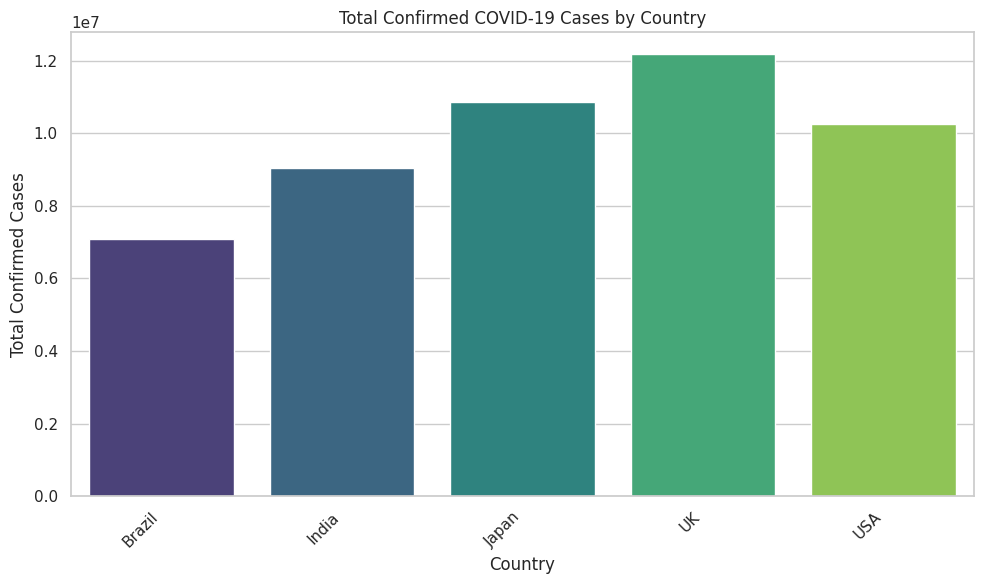

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=country_summary.index, y='Confirmed', data=country_summary, palette='viridis')
plt.title('Total Confirmed COVID-19 Cases by Country')
plt.xlabel('Country')
plt.ylabel('Total Confirmed Cases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

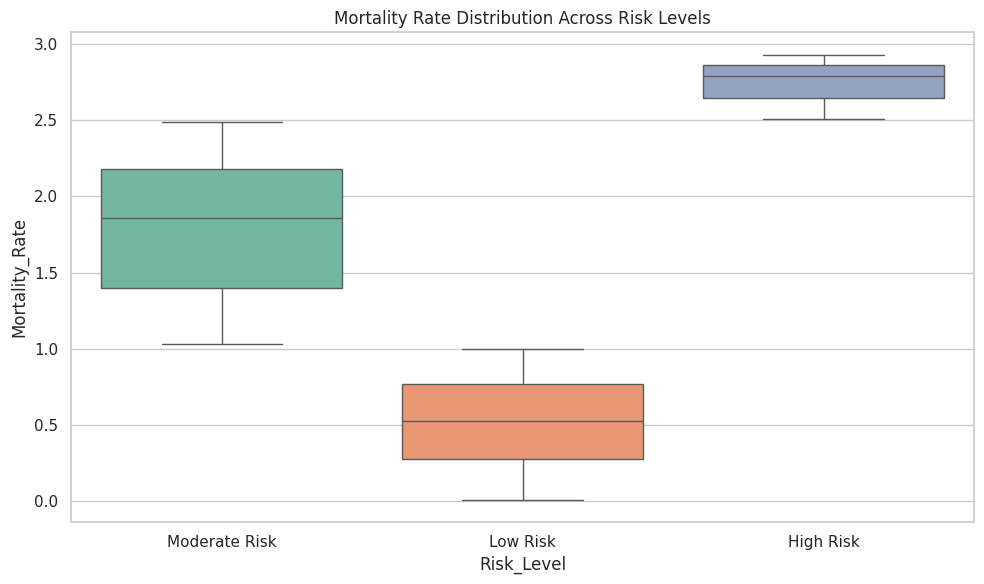

In [ ]:
# Boxplot: Distribution of Mortality Rate by Risk Level
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Risk_Level', y='Mortality_Rate', palette='Set2')
plt.title('Mortality Rate Distribution Across Risk Levels')
plt.tight_layout()
plt.show()

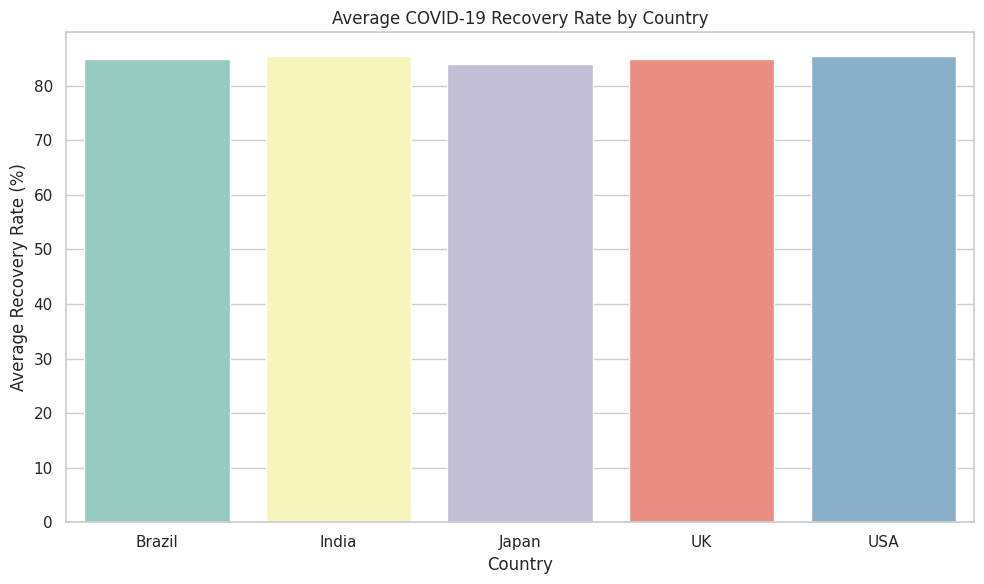

In [ ]:
# Calculate average recovery rate per country
avg_recovery_rate_by_country = df_clean.groupby('Country')['Recovery_Rate'].mean().reset_index()

# Create a bar plot for average recovery rate by country
plt.figure(figsize=(10, 6))
sns.barplot(x='Country', y='Recovery_Rate', data=avg_recovery_rate_by_country, palette='Set3')
plt.title('Average COVID-19 Recovery Rate by Country')
plt.xlabel('Country')
plt.ylabel('Average Recovery Rate (%)')
plt.tight_layout()
plt.show()

Question 1: Which state/region exhibits the highest average case mortality rate, and what business/policy recommendation follows?

In [ ]:
df['Mortality_Rate'] = (df['Deaths'] / df['Confirmed']) * 100
top_state_group = df.groupby(['Country', 'State'])['Mortality_Rate'].mean()
top_state = top_state_group.idxmax()
top_rate = top_state_group.max()

# Return a formatted string to display as cell output
f"{top_state} , {top_rate:.2f}%"

"('USA', 'California') , 1.76%"

Question 2: How does testing efficiency (Tests conducted per Confirmed Case) vary across countries?

In [ ]:
df['Tests_per_Case'] = df['Tests_Conducted'] / df['Confirmed']
testing_efficiency = df.groupby('Country')['Tests_per_Case'].mean()
testing_efficiency

,Tests_per_Case
Country,
Brazil,3.469395
India,3.182778
Japan,2.932617
UK,2.617707
USA,3.089248


Question 3: What is the Month-over-Month (MoM) percentage change in total confirmed cases?

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
monthly_cases = df.groupby(df['Date'].dt.to_period('M'))['Confirmed'].sum()
mom_growth = monthly_cases.pct_change() * 100
mom_growth

,Confirmed
Date,
2021-01,NaN
2021-02,0.231672
2021-03,-11.255618
2021-04,36.341632
2021-05,-8.450433
2021-06,9.009395
2021-07,-40.737690


Question 4: Which country bears the highest cumulative active case healthcare load?

In [ ]:
active_load = df.groupby('Country')['Active'].sum().sort_values(ascending=False)
active_load

,Active
Country,
UK,1590754
Japan,1575117
USA,1282188
India,1144493
Brazil,977904


Question 5: What is the statistical correlation between Vaccination Rate and Test Positivity Rate across records?

In [ ]:
df['Positivity_Rate'] = (df['Confirmed'] / df['Tests_Conducted']) * 100
# Updated to use the correct column name 'Vaccination_Rate'
correlation = df['Vaccination_Rate'].corr(df['Positivity_Rate'])
correlation

0.07984846408654954